# Stage 4: Hierarchical Clustering & Dendrograms

This notebook uses the Stage 3 distance matrix to discover groups of similar assets and to prepare cluster structure for later hierarchical risk parity analysis.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.clustering import (
    compute_linkage_matrix,
    assign_clusters,
    get_cluster_members,
    plot_dendrogram,
)
from src.covariance import compute_correlation_matrix, compute_distance_matrix
from src.data_pipeline import (
    SAMPLE_UNIVERSE,
    DataPreprocessor,
    YahooFinanceProvider,
)

## Load Stage 3 Outputs

The notebook first attempts to load previously saved Stage 3 outputs. If those saved artifacts are unavailable, it falls back to reconstructing Stage 3 data from the pipeline.

In [2]:
stage_3_archive = project_root / "notebooks" / "03_correlation_covariance" / "stage_03_outputs.pkl"
distance_matrix_df = None

if stage_3_archive.exists():
    stage_3_data = pd.read_pickle(stage_3_archive)
    distance_matrix_df = stage_3_data.get("distance_matrix_df")

if distance_matrix_df is None:
    symbols = list(SAMPLE_UNIVERSE)
    provider = YahooFinanceProvider()
    market_data = provider.get_market_data(symbols, "2020-01-01", "2024-12-31")
    prices_df = DataPreprocessor.handle_missing_values(market_data.prices_df)
    stage_2_outputs = DataPreprocessor.build_returns_risk_outputs(prices_df)
    log_returns_df = stage_2_outputs.log_returns_df
    correlation_matrix = compute_correlation_matrix(log_returns_df)
    distance_matrix_df = compute_distance_matrix(correlation_matrix)

distance_matrix_df

asset,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
asset,,,
GOLDBEES.NS,0.000000,0.719978,0.685352
HDFCBANK.NS,0.719978,0.000000,0.584126
TCS.NS,0.685352,0.584126,0.000000


## Distance Matrix

Display the Stage 3 distance matrix used for clustering.

In [3]:
display(distance_matrix_df)

asset,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
asset,,,
GOLDBEES.NS,0.000000,0.719978,0.685352
HDFCBANK.NS,0.719978,0.000000,0.584126
TCS.NS,0.685352,0.584126,0.000000


## Compute Linkage Matrix

Compute the hierarchical clustering linkage matrix using the Stage 3 distance matrix.

In [4]:
linkage_ward = compute_linkage_matrix(distance_matrix_df, method="ward")
linkage_average = compute_linkage_matrix(distance_matrix_df, method="average")
linkage_ward[:5]

array([[1.        , 2.        , 0.58412615, 2.        ],
       [0.        , 3.        , 0.73822904, 3.        ]])

## Dendrogram Comparison

Compare Ward and average linkage dendrograms to see how cluster structure changes.

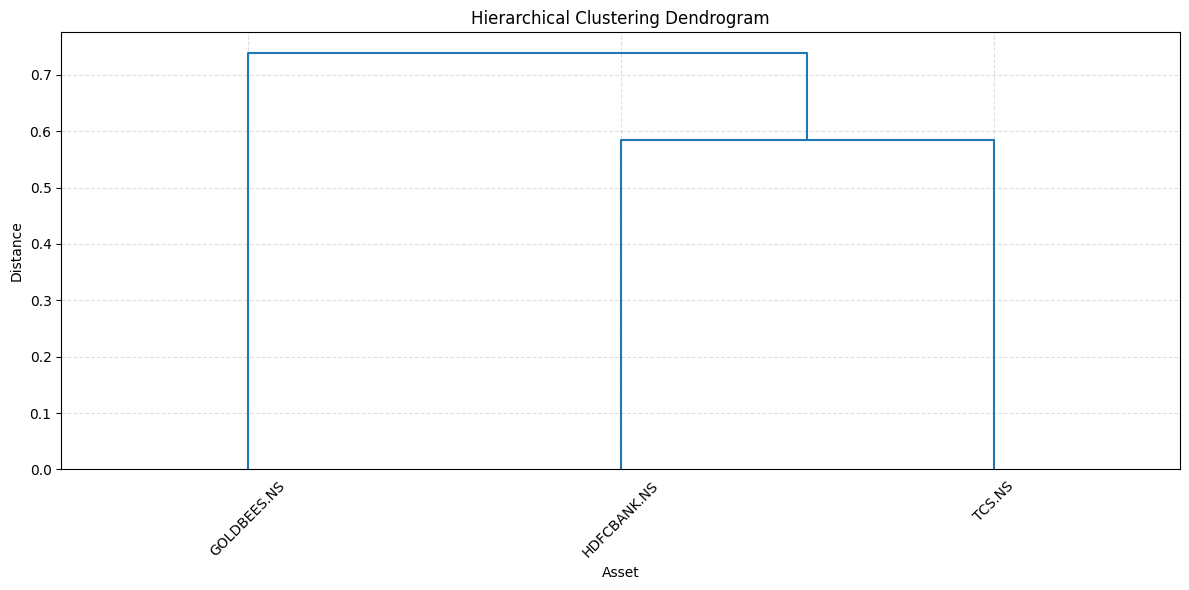

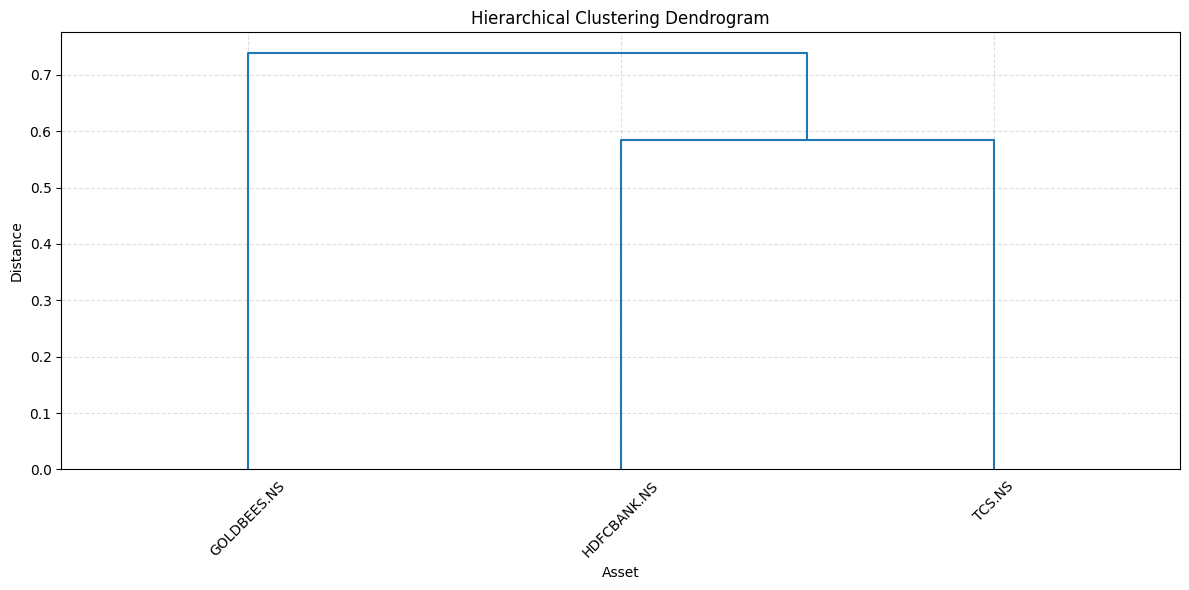

In [5]:
fig_ward = plot_dendrogram(linkage_ward, labels=distance_matrix_df.index.tolist())
fig_ward

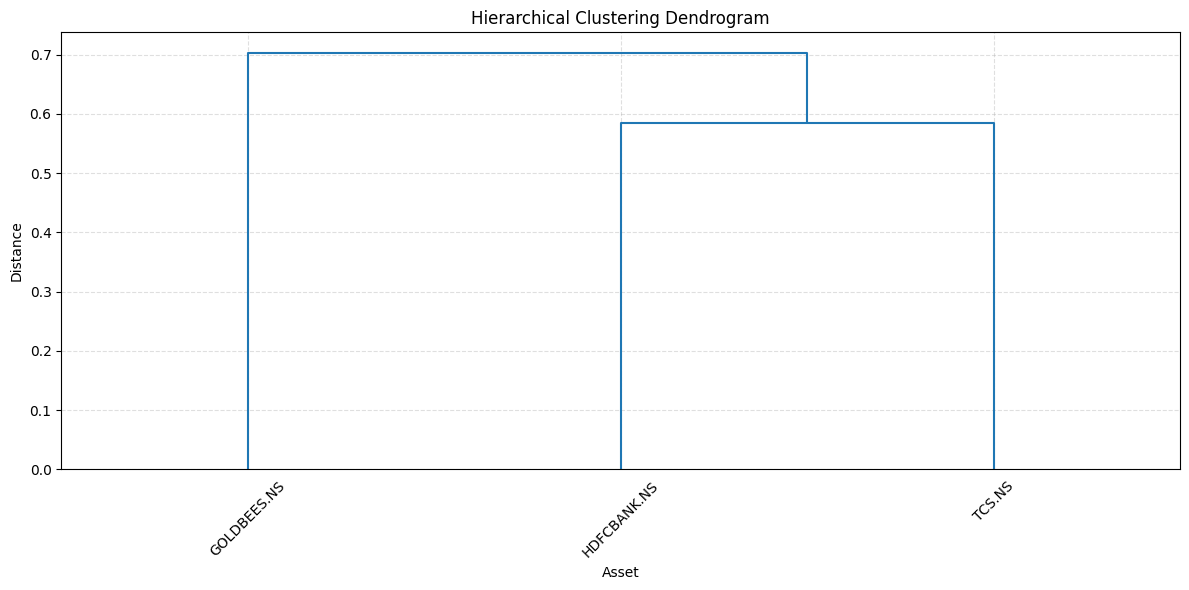

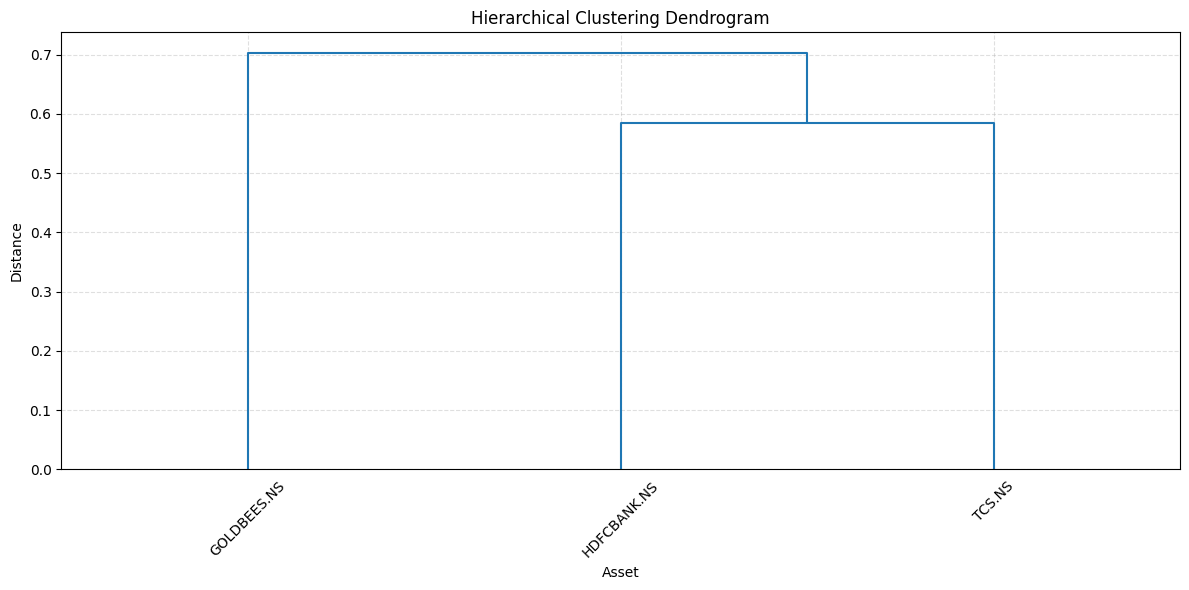

In [6]:
fig_average = plot_dendrogram(linkage_average, labels=distance_matrix_df.index.tolist())
fig_average

## Cluster Assignments

Create cluster assignments and display the resulting membership structure and summary.

In [8]:
n_clusters = 3


#Use ward clustering for the example assignment. The same distance matrix can be assigned with different linkage methods to compare groupings.


cluster_labels = assign_clusters(linkage_ward, n_clusters=n_clusters)
cluster_members = get_cluster_members(distance_matrix_df.index.tolist(), cluster_labels)
cluster_table = pd.DataFrame(
    [(label, asset) for label, members in cluster_members.items() for asset in members],
    columns=["cluster", "asset"],
)
cluster_table

,cluster,asset
0,1,GOLDBEES.NS
1,2,HDFCBANK.NS
2,3,TCS.NS


In [9]:
cluster_size = cluster_table.groupby("cluster").size().reset_index(name="size")
asset_cluster_map = {asset: int(label) for label, asset in zip(cluster_table["cluster"], cluster_table["asset"])}

display(cluster_size)
asset_cluster_map

,cluster,size
0,1,1
1,2,1
2,3,1


{'GOLDBEES.NS': 1, 'HDFCBANK.NS': 2, 'TCS.NS': 3}

## Interpretation

- **Correlation vs clustering**: correlation measures pairwise similarity, while clustering discovers groups of assets that form cohesive subsets across the full distance geometry.
- **Hidden structure**: clustering reveals sub-groups not obvious from single pair comparisons.
- **Same cluster**: two assets can share a cluster because their distances to the rest of the universe are similar, even if their direct correlation is not the maximum.
- **HRP readiness**: HRP uses these clusters to reduce concentration and allocate within coherent risk groups before weights are computed.
- **Concentration risk**: clustering groups similar assets, which helps avoid overweighting closely correlated names later in the allocation stage.